librerias

In [10]:
import os
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from collections import Counter
import seaborn as sns

Modelo a ocupar

In [11]:
from tensorflow.keras import layers, models

model_custom = models.Sequential([
    # Bloque 1: Extracción de características iniciales
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(100, 100, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 2: Extracción de patrones más complejos
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Bloque 3: Mayor profundidad para captar texturas de la frambuesa
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Aplanado
    layers.Flatten(),
    
    # Red Densa Clasificadora con Regularización
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), 
    # El Dropout "apaga" aleatoriamente a la mitad de las neuronas en cada paso de entrenamiento. Obliga a la red a no depender de un solo detalle y aprender a reconocer la frambuesa real.
    layers.Dense(1, activation='sigmoid')
])

model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_custom.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,697 (9.36 MB)

 Trainable params: 2,453,249 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

Entrenamiento de la CNN

In [12]:
import tensorflow as tf

#busca la carpeta con las frambuesas
RUTA_CARPETA = r"c:\Users\nico2\Documents\GitHub\clasificacion binaria de imagenes de frambuesas"
IMG_SIZE = (100, 100)
BATCH_SIZE = 30 #Toma las primeras 30 fotos de frambuesas.

print("Cargando imágenes")

# 2. Crear el set de ENTRENAMIENTO (80% de las imágenes)
train_ds = tf.keras.utils.image_dataset_from_directory(
    RUTA_CARPETA,
    validation_split=0.2,    # Reserva el 20% para validación
    subset="training",       # Especifica que este es el de entrenamiento
    seed=42,                 
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'      # 'binary' si son 2 carpetas, 'categorical' si son 3 o más
)

# 3. Crear el set de VALIDACIÓN (20% de las imágenes)
val_ds = tf.keras.utils.image_dataset_from_directory(
    RUTA_CARPETA,
    validation_split=0.2,    
    subset="validation",     # Especifica que este es el de examen
    seed=42,                 # Misma semilla
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print("Imágenes cargadas con éxito en memoria")

Cargando imágenes
Found 446 files belonging to 2 classes.
Using 357 files for training.
Found 446 files belonging to 2 classes.
Using 89 files for validation.
Imágenes cargadas con éxito en memoria


In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Configurar las reglas de seguridad (Callbacks)
early_stopping = EarlyStopping(
    monitor='val_loss',        # Vigilar el error en las imágenes de prueba 
    patience=5,                # Si pasan 5 "épocas" sin mejorar, detener el entrenamiento
    restore_best_weights=True  # Al detenerse, regresar a la mejor versión, no a la última
)

checkpoint = ModelCheckpoint(
    'modelo_frambuesas_robusto.h5', # Nombre del archivo donde se guardará tu IA
    monitor='val_loss',
    save_best_only=True             # Guardar solo si rompe su propio récord
)

# 2. Iniciar el entrenamiento
print("¡Iniciando el entrenamiento en la cinta transportadora virtual")

# Usamos la variable 'history' para guardar cómo le fue y graficarlo después
history = model_custom.fit(
    train_ds,                        # Tus datos de entrenamiento (la clase)
    validation_data=val_ds,          # Tus datos de validación (el examen)
    epochs=30,                       # Número MÁXIMO de vueltas completas a tus datos
    callbacks=[early_stopping, checkpoint] # Activamos los salvavidas
)

print("¡Entrenamiento finalizado y modelo guardado!")

¡Iniciando el entrenamiento en la cinta transportadora virtual
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.5322 - loss: 4.4430

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 322ms/step - accuracy: 0.5322 - loss: 4.4430 - val_accuracy: 0.4270 - val_loss: 21.8595
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.6919 - loss: 0.9727

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 298ms/step - accuracy: 0.6919 - loss: 0.9727 - val_accuracy: 0.5618 - val_loss: 3.3363
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.7507 - loss: 0.5470

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 0.7507 - loss: 0.5470 - val_accuracy: 0.5056 - val_loss: 1.5838
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8207 - loss: 0.4269

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 287ms/step - accuracy: 0.8207 - loss: 0.4269 - val_accuracy: 0.6966 - val_loss: 0.6278
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8852 - loss: 0.2802

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step - accuracy: 0.8852 - loss: 0.2802 - val_accuracy: 0.7303 - val_loss: 0.4950
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9160 - loss: 0.2312

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 288ms/step - accuracy: 0.9160 - loss: 0.2312 - val_accuracy: 0.7303 - val_loss: 0.4857
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 289ms/step - accuracy: 0.9356 - loss: 0.1604 - val_accuracy: 0.7416 - val_loss: 0.4965
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step - accuracy: 0.9412 - loss: 0.1411 - val_accuracy: 0.7528 - val_loss: 0.4917
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 280ms/step - accuracy: 0.9608 - loss: 0.0976 - val_accuracy: 0.7303 - val_loss: 0.6333
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.9720 - loss: 0.0998 - val_accuracy: 0.7640 - val_loss: 0.5341
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 0.9776 - loss: 0.0712 - val_accuracy: 0.7865 - val_loss: 0.5845
¡Entrenamiento finalizado y modelo guardado!


se utilizara validation_split esto le dice a TensorFlow que tome el 80% de las imágenes para que el modelo estudie y guarda el 20% restante para tomarle el examen", todo en memoria y sin mover ningún archivo de su lugar.

Ya se tienen las  variables train_ds y val_ds listas. Ahora solo se debe  pasar esos datos a la función fit del  modelo que se construyo anteriormente 

grafico comparativo

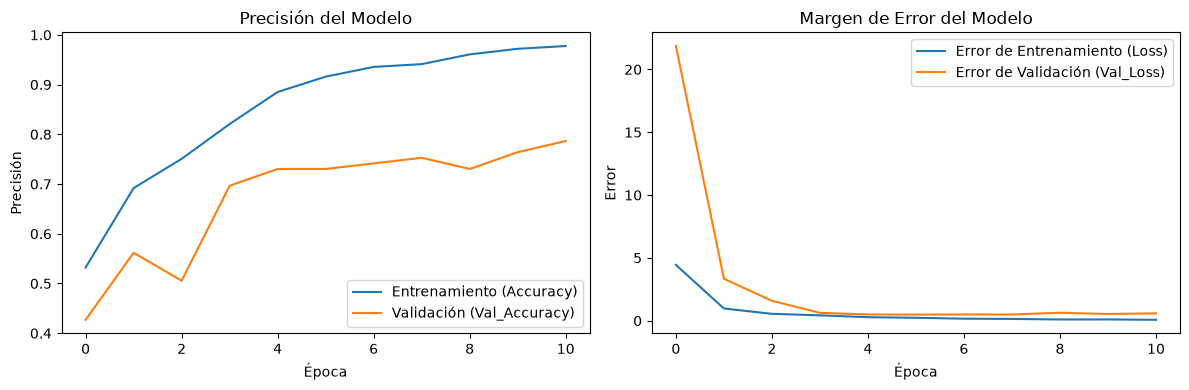

In [14]:
import matplotlib.pyplot as plt

# Crear una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica 1: Precisión (Accuracy)
ax1.plot(history.history['accuracy'], label='Entrenamiento (Accuracy)')
ax1.plot(history.history['val_accuracy'], label='Validación (Val_Accuracy)')
ax1.set_title('Precisión del Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend(loc='lower right')

# Gráfica 2: Pérdida/Error (Loss)
ax2.plot(history.history['loss'], label='Error de Entrenamiento (Loss)')
ax2.plot(history.history['val_loss'], label='Error de Validación (Val_Loss)')
ax2.set_title('Margen de Error del Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Error')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Generando predicciones.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


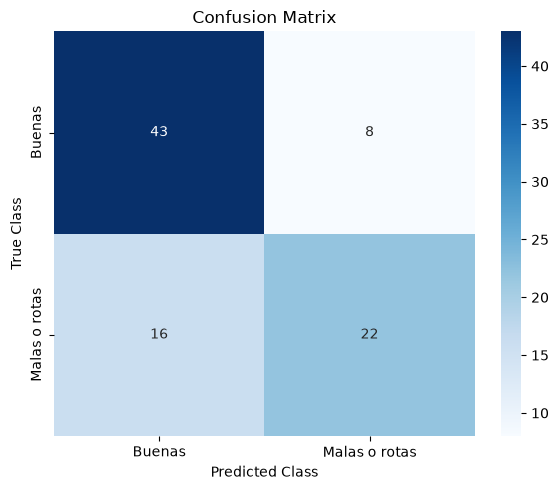


Reporte Detallado de Clasificación:

               precision    recall  f1-score   support

       Buenas       0.73      0.84      0.78        51
Malas o rotas       0.73      0.58      0.65        38

     accuracy                           0.73        89
    macro avg       0.73      0.71      0.71        89
 weighted avg       0.73      0.73      0.72        89



In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Extraer las imágenes y las etiquetas reales del set de validación
test_images = []
true_labels = []

# Recorremos el dataset de validación lote por lote
for images, labels in val_ds:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

# Unimos todos los lotes en un solo arreglo gigante
test_images = np.concatenate(test_images, axis=0)
true_labels = np.concatenate(true_labels, axis=0).flatten().astype(int)

# 2. Hacer que el modelo adivine (Predicciones)
print("Generando predicciones.")
predictions = model_custom.predict(test_images)

# Como la salida es una probabilidad (sigmoid), si es > 0.5 lo contamos como clase 1, sino clase 0
predicted_labels = (predictions > 0.5).astype(int).flatten()

# 3. Crear la Matriz de Confusión Matemática
cm = confusion_matrix(true_labels, predicted_labels)

# Definimos los nombres exactos que quieres en tu gráfica
class_names = ["Buenas", "Malas o rotas"] 

# 4. Graficar la Matriz (Estilo Seaborn)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          # Muestra los números adentro de los cuadros
    fmt='d',             # Formato de número entero (sin decimales)
    cmap='Blues',        # El esquema de color azul idéntico al de tu imagen
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

# 5. Imprimir el reporte detallado (Precision, Recall, F1-Score)
print("\nReporte Detallado de Clasificación:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))